# B01003 Time Series for Selected CA ZCTAs

This notebook loads yearly ACS files (2012-2024), filters selected ZIP/ZCTA codes, and plots `B01003_001E` over time.


In [6]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

ZIP_COL = "ZCTA5"
VALUE_COL = "B01003_001E"
FILE_PATTERN = "acs_*_demographics_ca_zcta.csv"
YEAR_RE = re.compile(r"acs_(\d{4})_demographics_ca_zcta\.csv$")

DEFAULT_ZIPS = [
    "92602",
    "92603",
    "92604",
    "92606",
    "92612",
    "92614",
    "92617",
    "92618",
    "92620",
    #"92697",
]


def load_series_rows(data_dir: Path, target_zips: list[str]) -> pd.DataFrame:
    records = []
    target_set = set(target_zips)

    for path in sorted(data_dir.glob(FILE_PATTERN)):
        match = YEAR_RE.match(path.name)
        if not match:
            continue
        year = int(match.group(1))

        try:
            df = pd.read_csv(path, usecols=[ZIP_COL, VALUE_COL], dtype=str)
        except ValueError as exc:
            raise ValueError(
                f"{path.name} is missing required columns {ZIP_COL}/{VALUE_COL}"
            ) from exc

        df[ZIP_COL] = df[ZIP_COL].astype(str).str.strip().str.zfill(5)
        df = df[df[ZIP_COL].isin(target_set)].copy()
        if df.empty:
            continue

        df[VALUE_COL] = pd.to_numeric(
            df[VALUE_COL].astype(str).str.replace(",", "", regex=False),
            errors="coerce",
        )
        df = df.drop_duplicates(subset=[ZIP_COL], keep="first")
        df["year"] = year
        records.append(df[[ZIP_COL, "year", VALUE_COL]])

    if not records:
        raise RuntimeError("No matching data found for target ZIP codes.")

    result = pd.concat(records, ignore_index=True)
    return result.sort_values(["year", ZIP_COL]).reset_index(drop=True)


def plot_series(df: pd.DataFrame, target_zips: list[str], out_path: Path) -> None:
    pivot = df.pivot(index="year", columns=ZIP_COL, values=VALUE_COL)
    pivot = pivot.reindex(columns=target_zips)
    pivot = pivot.sort_index()

    ax = pivot.plot(figsize=(12, 7), marker="o", linewidth=2)
    ax.set_title("Total Population Estimate From 2012-2024 for Irvine ZCTAs")
    ax.set_xlabel("Year")
    ax.set_ylabel("Population (Estimate)")
    ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.4)
    ax.legend(title="ZCTA5", ncol=2, frameon=False)

    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.show()


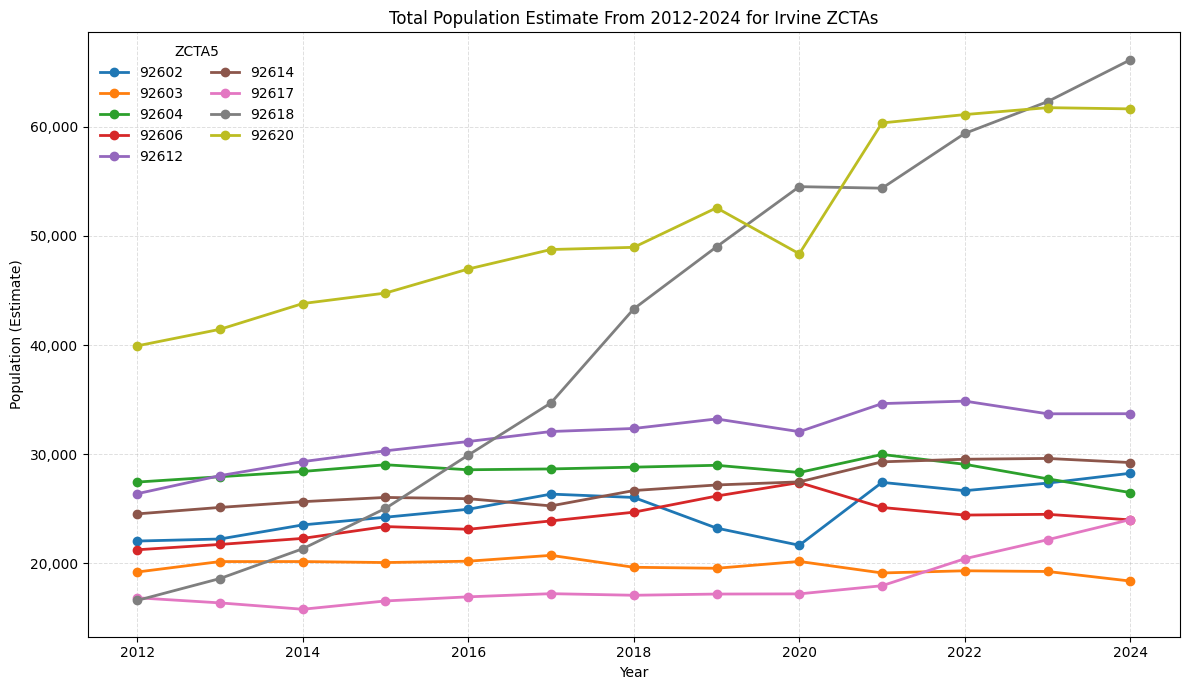

Loaded years: 2012-2024 (13 years)
ZIP codes requested: 92602, 92603, 92604, 92606, 92612, 92614, 92617, 92618, 92620
Output plot: b01003_selected_zctas_timeseries.png


In [7]:
PROJECT_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'data' / 'zcta_archive' / 'raw').exists())
data_dir = PROJECT_ROOT / 'data' / 'zcta_archive' / 'raw'
output_path = PROJECT_ROOT / 'outputs' / 'zcta-exploration' / 'b01003_selected_zctas_timeseries.png'
output_path.parent.mkdir(parents=True, exist_ok=True)
target_zips = [str(z).zfill(5) for z in DEFAULT_ZIPS]

df = load_series_rows(data_dir, target_zips)
plot_series(df, target_zips, output_path)

years = sorted(df['year'].unique().tolist())
print(f"Loaded years: {years[0]}-{years[-1]} ({len(years)} years)")
print(f"ZIP codes requested: {', '.join(target_zips)}")
print(f"Output plot: {output_path}")
